# EDAノートブック

本ノートブックは、分析業務で使うEDAを固定手順で実行するための定型版です。
可視化結果は相対パスで `reports/figures` に保存します。


## 固定EDA計画
1. データ読み込みと基本確認
2. 列型・記述統計の確認
3. 欠損率の集計と可視化
4. 数値列の分布確認
5. カテゴリ列の主要分布確認
6. 目的変数の分布と偏り確認
7. 数値特徴量の相関確認
8. 日付列の時系列傾向確認（存在時）
9. 観察結果サマリ


In [1]:
from pathlib import Path
import warnings

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")
warnings.filterwarnings("ignore", message="Glyph .* missing from font")
plt.rcParams["axes.unicode_minus"] = False

JP_FONT_CANDIDATES = [
    "Yu Gothic",
    "Meiryo",
    "MS Gothic",
    "Noto Sans CJK JP",
    "IPAexGothic",
    "IPAGothic",
    "TakaoGothic",
]


def configure_japanese_font() -> str:
    available = {f.name for f in fm.fontManager.ttflist}
    for name in JP_FONT_CANDIDATES:
        if name in available:
            plt.rcParams["font.family"] = name
            return name
    plt.rcParams["font.sans-serif"] = JP_FONT_CANDIDATES + list(plt.rcParams.get("font.sans-serif", []))
    return ""


selected_font = configure_japanese_font()
if selected_font:
    print(f"日本語フォント: {selected_font}")
else:
    print("日本語フォント候補が見つからないため、既定フォントで描画します。")

ENCODINGS = ("utf-8-sig", "utf-8", "cp932", "shift_jis", "euc_jp")

cwd = Path.cwd()
if (cwd / "configs" / "project_config.json").exists():
    analysis_root = cwd
elif (cwd.name == "notebooks") and (cwd.parent / "configs" / "project_config.json").exists():
    analysis_root = cwd.parent
elif (cwd / "artifacts" / "analysis_project" / "configs" / "project_config.json").exists():
    analysis_root = cwd / "artifacts" / "analysis_project"
else:
    analysis_root = cwd

FIG_DIR = analysis_root / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def load_csv_auto(path: Path):
    sep = "	" if path.suffix.lower() == ".tsv" else ","
    for enc in ENCODINGS:
        try:
            return pd.read_csv(path, encoding=enc, sep=sep), enc
        except UnicodeDecodeError:
            continue
    raise RuntimeError("CSVを既知エンコーディングで読み込めませんでした")


def is_pure_day_number_column(series: pd.Series) -> bool:
    numeric = pd.to_numeric(series, errors="coerce").dropna()
    if numeric.empty:
        return False
    if not np.all(np.isclose(numeric, np.round(numeric))):
        return False
    return bool(((numeric >= 1) & (numeric <= 31)).all())


日本語フォント: Yu Gothic


In [2]:
csv_rel = Path("data/train.tsv")
candidates = [
    analysis_root / csv_rel,
    Path("data/train.tsv"),
    Path("artifacts/analysis_project") / csv_rel,
]
csv_path = next((p for p in candidates if p.exists()), candidates[0])
df, used_encoding = load_csv_auto(csv_path)
target_col = "cnt"
if target_col not in df.columns:
    target_col = df.columns[-1]
date_col_hint = "dteday".strip() or None

print(f"読み込みエンコーディング: {used_encoding}")
print(f"行数: {len(df):,} / 列数: {df.shape[1]:,}")
print(f"目的変数列: {target_col}")
display(df.head(10))


読み込みエンコーディング: utf-8-sig
行数: 8,645 / 列数: 15
目的変数列: cnt


,id,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,14


## 1. データ概要


In [3]:
try:
    overview = pd.DataFrame({
        '項目': ['行数', '列数', '目的変数'],
        '値': [df.shape[0], df.shape[1], target_col if target_col in df.columns else 'なし']
    })
    print(overview)
    print('\n列情報')
    print(pd.DataFrame({'列名': df.columns, 'データ型': df.dtypes.astype(str).values, '欠損数': df.isnull().sum().values}))
    print('\n先頭5行')
    print(df.head())
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: overview_code: {_eda_exc}")
    dtype_summary = (
        df.dtypes.astype(str)
        .rename("dtype")
        .reset_index()
        .rename(columns={"index": "column"})
    )
    type_counts = dtype_summary["dtype"].value_counts().rename_axis("dtype").reset_index(name="count")
    print("列型サマリ")
    display(type_counts)
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    category_cols = [c for c in df.columns if c not in numeric_cols]
    print(f"数値列数: {len(numeric_cols)} / カテゴリ列数: {len(category_cols)}")
    display(dtype_summary.head(30))


     項目     値
0    行数  8645
1    列数    15
2  目的変数   cnt

列情報
            列名     データ型  欠損数
0           id    int64    0
1       dteday      str    0
2       season    int64    0
3           yr    int64    0
4         mnth    int64    0
5           hr    int64    0
6      holiday    int64    0
7      weekday    int64    0
8   workingday    int64    0
9   weathersit    int64    0
10        temp  float64    0
11       atemp  float64    0
12         hum  float64    0
13   windspeed  float64    0
14         cnt    int64    0

先頭5行
   id      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0   1  2011-01-01       1   0     1   0        0        6           0   
1   2  2011-01-01       1   0     1   1        0        6           0   
2   3  2011-01-01       1   0     1   2        0        6           0   
3   4  2011-01-01       1   0     1   3        0        6           0   
4   5  2011-01-01       1   0     1   4        0        6           0   

   weathersit  temp   atemp   

## 2. 欠損分析


Empty DataFrame
Columns: [列名, 欠損率]
Index: []


C:\Users\hikeshita\AppData\Local\Temp\ipykernel_26828\2727228635.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='欠損率', y='列名', palette='Blues_r')


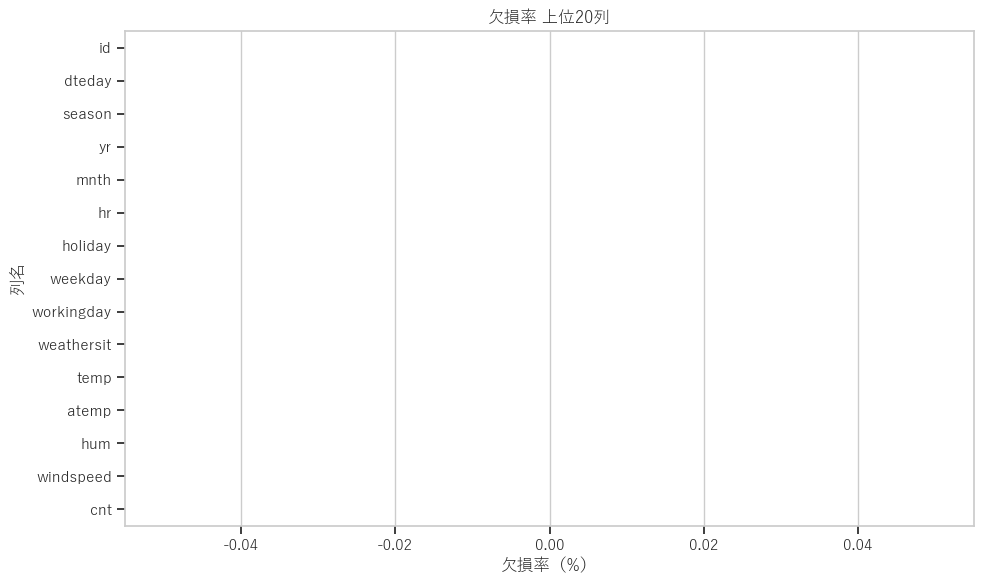

In [4]:
try:
    missing_rate = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    missing_df = missing_rate.reset_index()
    missing_df.columns = ['列名', '欠損率']
    print(missing_df[missing_df['欠損率'] > 0])
    plt.figure(figsize=(10, 6))
    plot_df = missing_df.head(20)
    sns.barplot(data=plot_df, x='欠損率', y='列名', palette='Blues_r')
    plt.title('欠損率 上位20列')
    plt.xlabel('欠損率（%）')
    plt.ylabel('列名')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'missing_rate_top20.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: missing_code: {_eda_exc}")
    missing_rate = (df.isna().mean() * 100).sort_values(ascending=False)
    display(missing_rate.rename("欠損率(%)").to_frame().head(20))
    top_missing = missing_rate.head(20)
    fig, ax = plt.subplots(figsize=(12, 5))
    top_missing.plot(kind="bar", ax=ax, color="#4c78a8")
    ax.set_title("欠損率 上位20列")
    ax.set_ylabel("欠損率(%)")
    ax.set_xlabel("列名")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "missing_rate_top20.png", dpi=160, bbox_inches="tight")
    plt.show()


## 3. 数値特徴量の分布


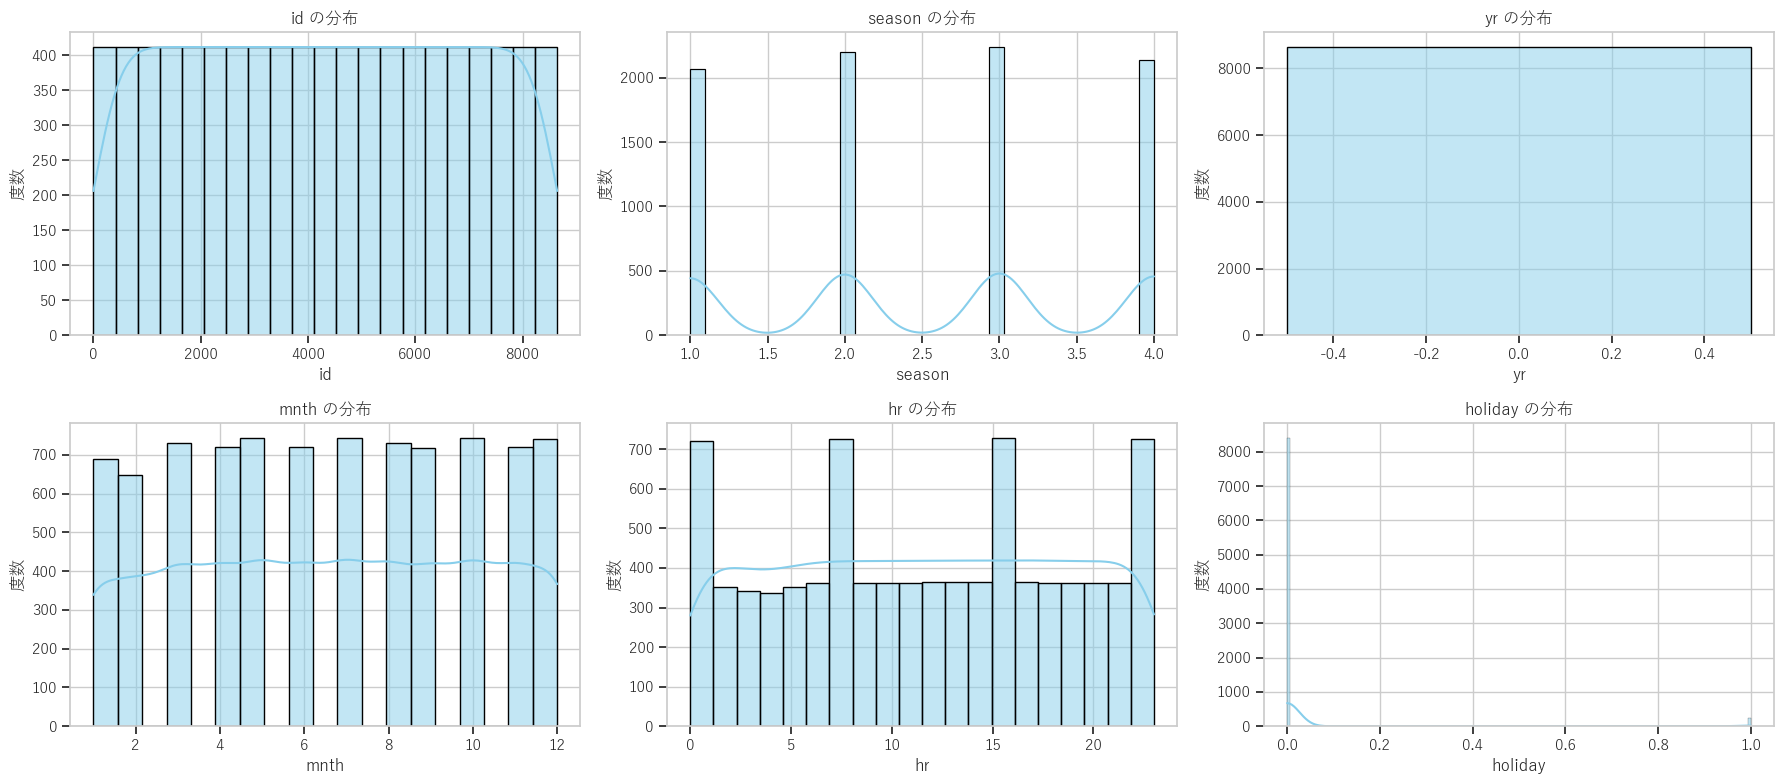

             count         mean          std   min        25%        50%  \
id          8645.0  4323.000000  2495.740872  1.00  2162.0000  4323.0000   
season      8645.0     2.513592     1.105477  1.00     2.0000     3.0000   
yr          8645.0     0.000000     0.000000  0.00     0.0000     0.0000   
mnth        8645.0     6.573973     3.428147  1.00     4.0000     7.0000   
hr          8645.0    11.573626     6.907822  0.00     6.0000    12.0000   
holiday     8645.0     0.027646     0.163966  0.00     0.0000     0.0000   
weekday     8645.0     3.012724     2.006370  0.00     1.0000     3.0000   
workingday  8645.0     0.683748     0.465040  0.00     0.0000     1.0000   
weathersit  8645.0     1.437594     0.653859  1.00     1.0000     1.0000   
temp        8645.0     0.489069     0.197943  0.02     0.3200     0.5000   
atemp       8645.0     0.469000     0.176760  0.00     0.3182     0.4848   
hum         8645.0     0.643430     0.196293  0.00     0.4900     0.6500   
windspeed   

In [5]:
try:
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if target_col in num_cols:
        pass
    plot_cols = [c for c in num_cols][:6]
    if len(plot_cols) > 0:
        fig, axes = plt.subplots(nrows=int(np.ceil(len(plot_cols)/3)), ncols=3, figsize=(18, 4 * int(np.ceil(len(plot_cols)/3))))
        axes = np.array(axes).reshape(-1)
        for ax, col in zip(axes, plot_cols):
            sns.histplot(df[col].dropna(), kde=True, ax=ax, color='skyblue')
            ax.set_title(f'{col} の分布')
            ax.set_xlabel(col)
            ax.set_ylabel('度数')
        for ax in axes[len(plot_cols):]:
            ax.axis('off')
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'numeric_distribution_top6.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
    summary_num = df[num_cols].describe().T if len(num_cols) > 0 else pd.DataFrame()
    print(summary_num)
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: numeric_code: {_eda_exc}")
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    if numeric_cols:
        display(df[numeric_cols].describe().T.head(20))
    target_col_local = "cnt"
    if target_col_local not in df.columns:
        target_col_local = df.columns[-1]
    plot_cols = [c for c in numeric_cols if c != target_col_local][:6]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        if i < len(plot_cols):
            col = plot_cols[i]
            sns.histplot(df[col], bins=30, ax=ax, color="#1f77b4")
            ax.set_title(f"{col} の分布")
        else:
            ax.axis("off")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "numeric_distribution_top6.png", dpi=160, bbox_inches="tight")
    plt.show()


## 4. カテゴリ特徴量の分布


C:\Users\hikeshita\AppData\Local\Temp\ipykernel_26828\3642036161.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
C:\Users\hikeshita\AppData\Local\Temp\ipykernel_26828\3642036161.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, ax=ax, palette='viridis')


C:\Users\hikeshita\AppData\Local\Temp\ipykernel_26828\3642036161.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, ax=ax, palette='viridis')
C:\Users\hikeshita\AppData\Local\Temp\ipykernel_26828\3642036161.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, ax=ax, palette='viridis')


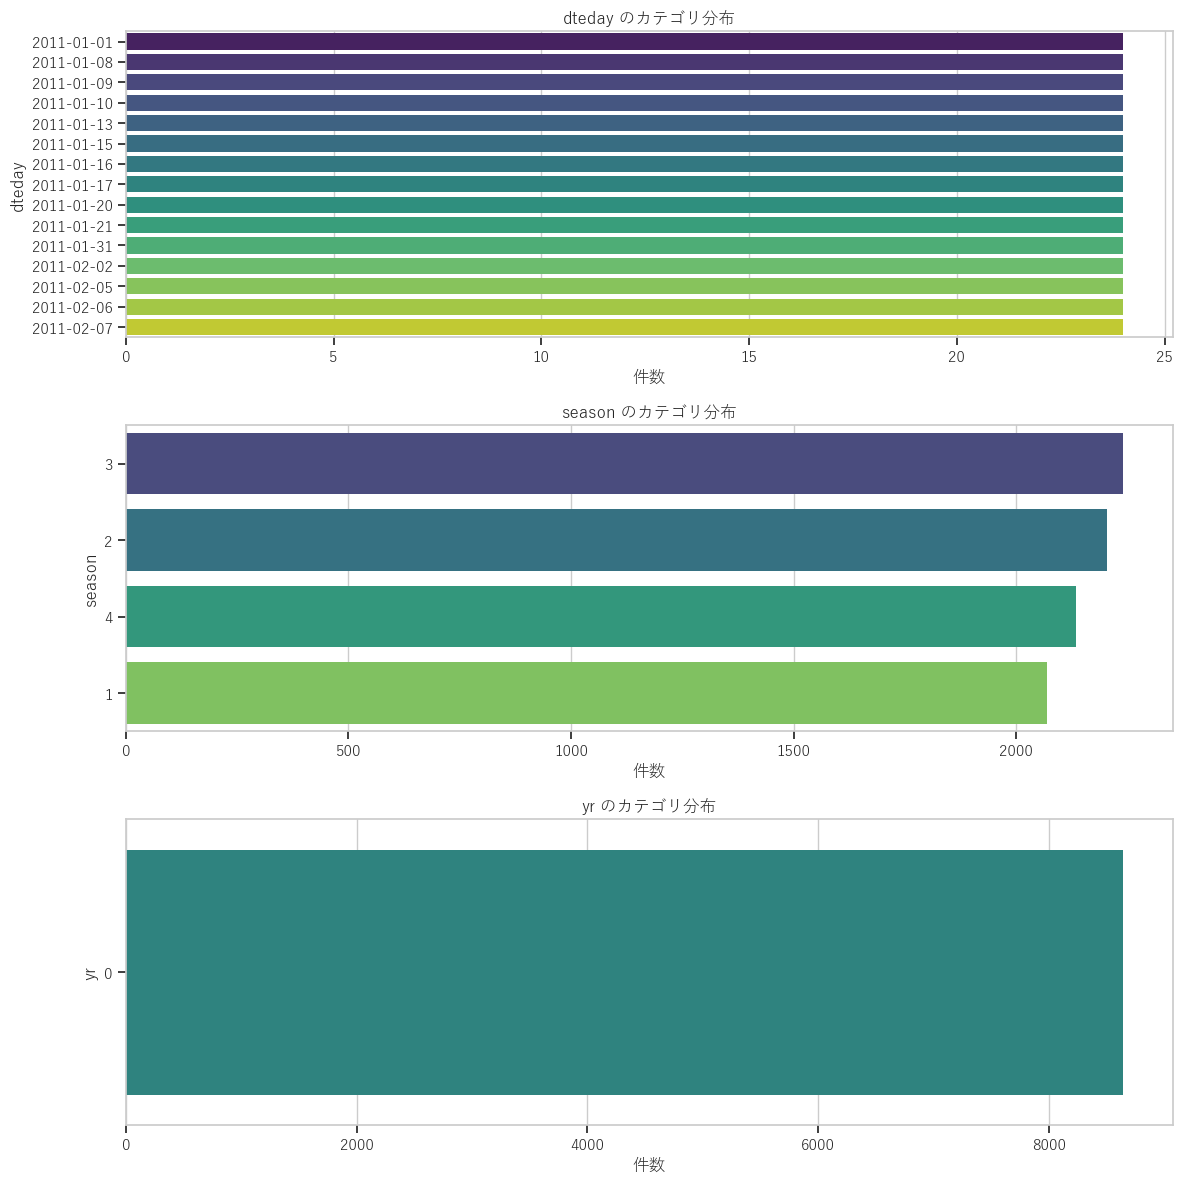


【dteday】
dteday
2011-01-01    24
2011-01-08    24
2011-01-09    24
2011-01-10    24
2011-01-13    24
2011-01-15    24
2011-01-16    24
2011-01-17    24
2011-01-20    24
2011-01-21    24
2011-01-31    24
2011-02-02    24
2011-02-05    24
2011-02-06    24
2011-02-07    24
2011-02-08    24
2011-02-12    24
2011-02-14    24
2011-02-17    24
2011-02-18    24
Name: count, dtype: int64

【season】
season
3    2240
2    2203
4    2134
1    2068
Name: count, dtype: int64

【yr】
yr
0    8645
Name: count, dtype: int64

【mnth】
mnth
5     744
7     744
10    743
12    741
8     731
3     730
6     720
4     719
11    719
9     717
1     688
2     649
Name: count, dtype: int64

【holiday】
holiday
0    8406
1     239
Name: count, dtype: int64

【weekday】
weekday
6    1264
5    1239
1    1235
0    1231
3    1229
4    1225
2    1222
Name: count, dtype: int64

【workingday】
workingday
1    5911
0    2734
Name: count, dtype: int64

【weathersit】
weathersit
1    5645
2    2218
3     781
4       1
Name: count, d

In [6]:
try:
    def _is_low_cardinality_numeric(series):
        s = series.dropna()
        if s.empty:
            return False
        return pd.api.types.is_numeric_dtype(series) and s.nunique() <= 12

    cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    cat_cols += [c for c in df.columns if c not in cat_cols and _is_low_cardinality_numeric(df[c]) and c != target_col]
    cat_cols = list(dict.fromkeys(cat_cols))
    plot_cols = cat_cols[:3]
    if len(plot_cols) > 0:
        fig, axes = plt.subplots(len(plot_cols), 1, figsize=(12, 4 * len(plot_cols)))
        if len(plot_cols) == 1:
            axes = [axes]
        for ax, col in zip(axes, plot_cols):
            vc = df[col].astype(str).fillna('欠損').value_counts().head(15)
            sns.barplot(x=vc.values, y=vc.index, ax=ax, palette='viridis')
            ax.set_title(f'{col} のカテゴリ分布')
            ax.set_xlabel('件数')
            ax.set_ylabel(col)
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'categorical_distribution_top3.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
    for col in cat_cols:
        print(f'\n【{col}】')
        print(df[col].astype(str).value_counts(dropna=False).head(20))
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: categorical_code: {_eda_exc}")
    category_cols = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]
    plot_cols = category_cols[:3]
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    for i, ax in enumerate(axes):
        if i < len(plot_cols):
            col = plot_cols[i]
            vc = df[col].astype(str).fillna("欠損").value_counts().head(10)
            vc.plot(kind="bar", ax=ax, color="#59a14f")
            ax.set_title(f"{col} 上位カテゴリ")
            ax.tick_params(axis="x", rotation=45)
        else:
            ax.axis("off")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "categorical_distribution_top3.png", dpi=160, bbox_inches="tight")
    plt.show()


## 5. 目的変数分析


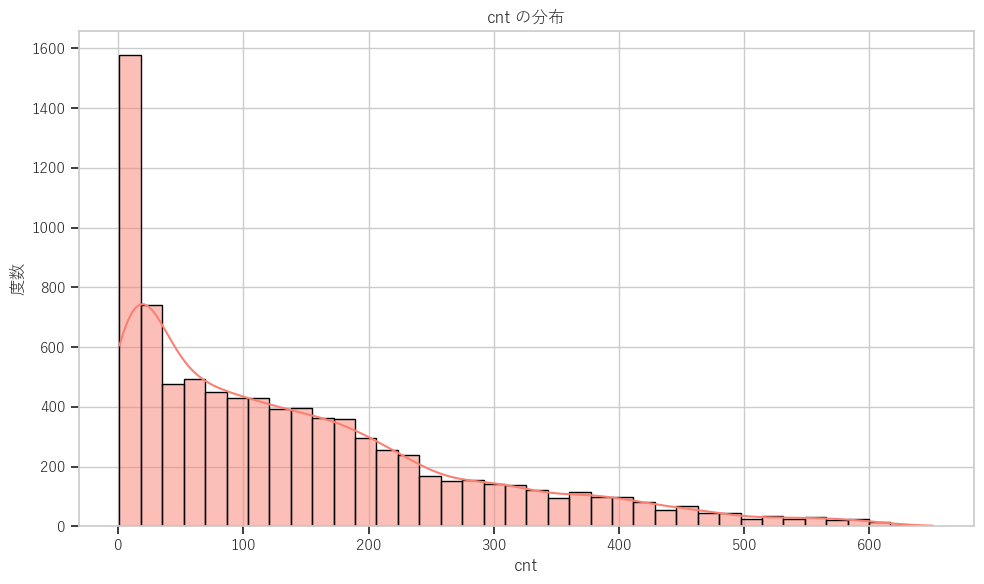

count    8645.000000
mean      143.794448
std       133.797854
min         1.000000
25%        31.000000
50%       109.000000
75%       211.000000
max       651.000000
Name: cnt, dtype: float64
歪度             1.131566
尖度             0.759793
外れ値件数_IQR    215.000000
dtype: float64


In [7]:
try:
    if target_col in df.columns:
        plt.figure(figsize=(10, 6))
        sns.histplot(df[target_col].dropna(), kde=True, color='salmon')
        plt.title(f'{target_col} の分布')
        plt.xlabel(target_col)
        plt.ylabel('度数')
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'target_distribution.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
        print(df[target_col].describe())
        q1 = df[target_col].quantile(0.25)
        q3 = df[target_col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_count = ((df[target_col] < lower) | (df[target_col] > upper)).sum()
        print(pd.Series({'歪度': df[target_col].skew(), '尖度': df[target_col].kurt(), '外れ値件数_IQR': outlier_count}))
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: target_code: {_eda_exc}")
    series = df[target_col]
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    if pd.api.types.is_numeric_dtype(series):
        uniq = series.dropna().nunique()
        if uniq > 20:
            sns.histplot(series.dropna(), bins=30, ax=ax[0], color="#f28e2b")
            ax[0].set_title("目的変数ヒストグラム")
            sns.boxplot(x=series.dropna(), ax=ax[1], color="#e15759")
            ax[1].set_title("目的変数ボックスプロット")
        else:
            vc = series.value_counts(dropna=False).sort_index()
            vc.plot(kind="bar", ax=ax[0], color="#f28e2b")
            ax[0].set_title("目的変数カテゴリ分布")
            (vc / vc.sum() * 100).round(2).plot(kind="bar", ax=ax[1], color="#e15759")
            ax[1].set_title("目的変数カテゴリ比率(%)")
    else:
        vc = series.astype(str).fillna("欠損").value_counts().head(20)
        vc.plot(kind="bar", ax=ax[0], color="#f28e2b")
        ax[0].set_title("目的変数カテゴリ分布")
        (vc / vc.sum() * 100).round(2).plot(kind="bar", ax=ax[1], color="#e15759")
        ax[1].set_title("目的変数カテゴリ比率(%)")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "target_distribution.png", dpi=160, bbox_inches="tight")
    plt.show()


## 6. 相関分析


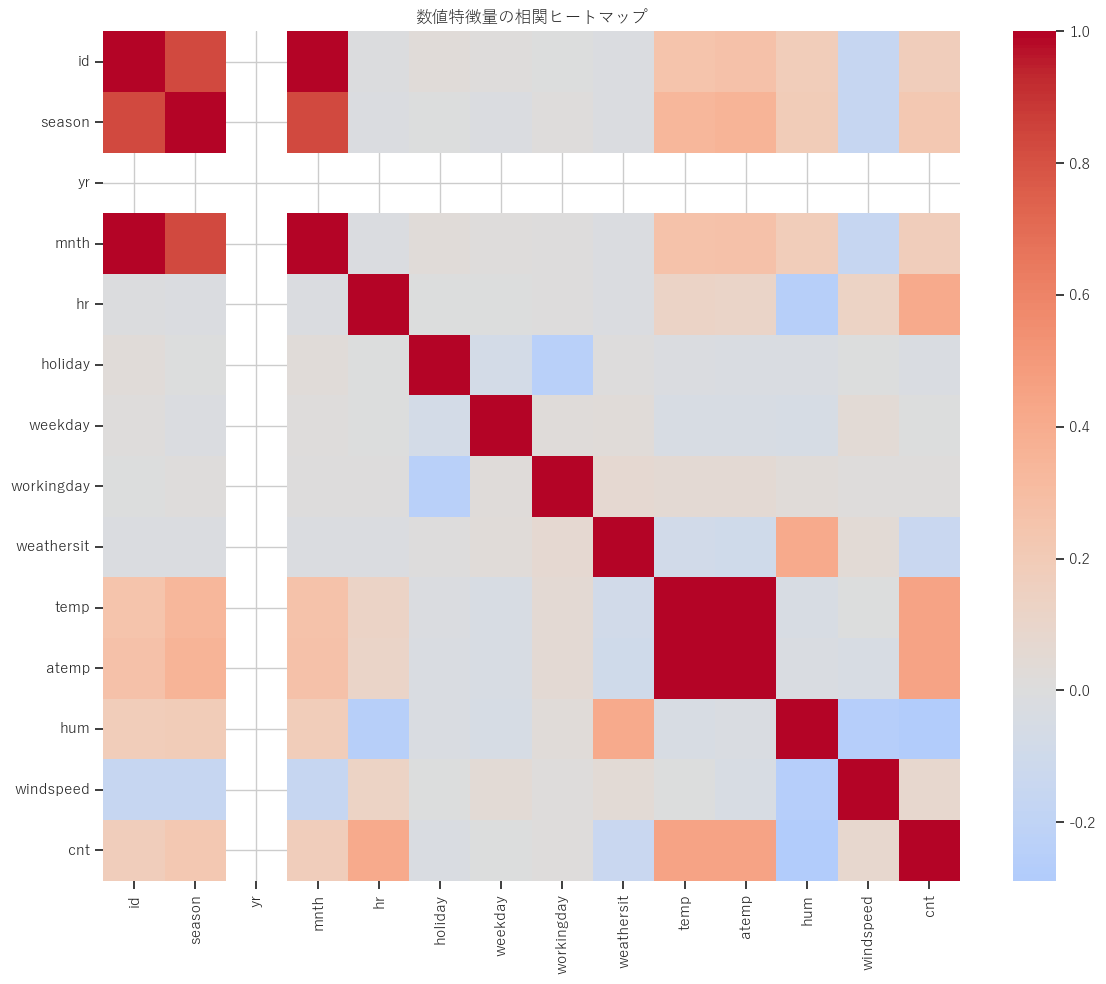

cnt           1.000000
temp          0.451233
atemp         0.447029
hr            0.407486
season        0.221719
mnth          0.179273
id            0.178084
windspeed     0.085356
workingday    0.011704
weekday      -0.004321
holiday      -0.022912
weathersit   -0.143288
hum          -0.288615
yr                 NaN
Name: cnt, dtype: float64


In [8]:
try:
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if len(num_cols) >= 2:
        corr = df[num_cols].corr(numeric_only=True)
        plt.figure(figsize=(12, 10))
        sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, square=False)
        plt.title('数値特徴量の相関ヒートマップ')
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'feature_correlation_heatmap.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
        if target_col in corr.columns:
            target_corr = corr[target_col].sort_values(ascending=False)
            print(target_corr)
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: corr_code: {_eda_exc}")
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    fig, ax = plt.subplots(figsize=(10, 8))
    if len(numeric_cols) >= 2:
        corr = df[numeric_cols[:20]].corr(numeric_only=True)
        sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax)
        ax.set_title("数値特徴量の相関ヒートマップ（先頭20列）")
    else:
        ax.axis("off")
        ax.text(0.5, 0.5, "相関分析に十分な数値列がありません", ha="center", va="center", fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "feature_correlation_heatmap.png", dpi=160, bbox_inches="tight")
    plt.show()


## 7. 日付分析


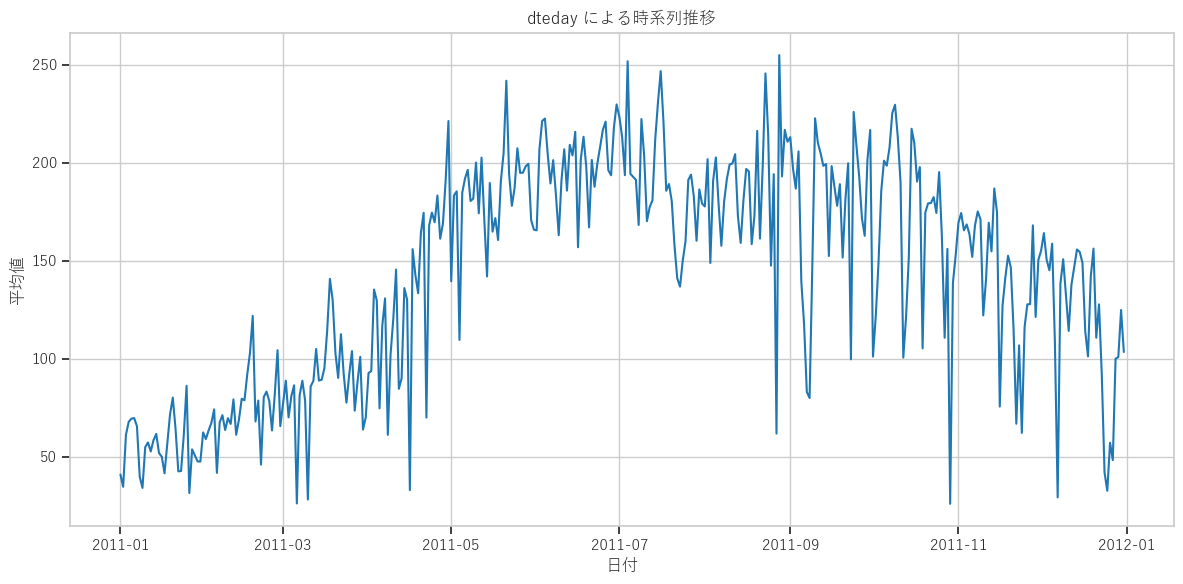

        最小日付       最大日付   日数
0 2011-01-01 2011-12-31  365


In [9]:
try:
    def is_pure_day_number_column(series):
        s = series.dropna()
        if s.empty:
            return False
        numeric = pd.to_numeric(s, errors='coerce')
        if numeric.isna().any():
            return False
        numeric = numeric.astype(float)
        return numeric.between(1, 31).all() and numeric.nunique() >= min(7, len(numeric))

    date_col = None
    candidate_cols = []
    if 'date_col_hint' in locals() and date_col_hint is not None:
        if isinstance(date_col_hint, str):
            candidate_cols.append(date_col_hint)
        elif isinstance(date_col_hint, (list, tuple)):
            candidate_cols.extend(list(date_col_hint))
    for c in df.columns:
        if c not in candidate_cols:
            candidate_cols.append(c)

    for col in candidate_cols:
        if col not in df.columns:
            continue
        if is_pure_day_number_column(df[col]):
            continue
        parsed = pd.to_datetime(df[col], errors='coerce')
        if parsed.notna().mean() >= 0.8:
            date_col = col
            break

    if date_col is not None:
        dt = pd.to_datetime(df[date_col], errors='coerce')
        tmp = df.loc[dt.notna()].copy()
        tmp['_date_'] = dt[dt.notna()]
        daily = tmp.groupby('_date_')[target_col].mean().reset_index() if target_col in tmp.columns else tmp.groupby('_date_').size().reset_index(name='件数')
        plt.figure(figsize=(12, 6))
        y_col = target_col if target_col in daily.columns else '件数'
        sns.lineplot(data=daily.sort_values('_date_'), x='_date_', y=y_col)
        plt.title(f'{date_col} による時系列推移')
        plt.xlabel('日付')
        plt.ylabel('平均値' if y_col == target_col else '件数')
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'date_feature_trend.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
        date_summary = pd.DataFrame({
            '最小日付': [tmp['_date_'].min()],
            '最大日付': [tmp['_date_'].max()],
            '日数': [tmp['_date_'].dt.normalize().nunique()]
        })
        print(date_summary)
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: date_code: {_eda_exc}")
    date_col = "dteday".strip() or date_col_hint
    fig, ax = plt.subplots(figsize=(12, 4))
    if date_col and date_col in df.columns and date_col != target_col:
        pure_day = is_pure_day_number_column(df[date_col])
        if pure_day:
            ax.axis("off")
            ax.text(0.5, 0.5, f"{date_col} は純粋な日番号列のため日付展開を行いません", ha="center", va="center", fontsize=12)
        else:
            parsed = pd.to_datetime(df[date_col], errors="coerce")
            valid = parsed.notna()
            if valid.sum() > 0:
                tmp = df.loc[valid, [target_col]].copy()
                tmp["_date"] = parsed.loc[valid]
                if pd.api.types.is_numeric_dtype(tmp[target_col]):
                    monthly = tmp.set_index("_date")[target_col].resample("M").mean()
                    monthly.plot(ax=ax, color="#4e79a7", marker="o")
                    ax.set_title("月次の目的変数平均")
                    ax.set_ylabel("平均値")
                else:
                    monthly = tmp.assign(_value=1).set_index("_date")["_value"].resample("M").sum()
                    monthly.plot(ax=ax, color="#4e79a7", marker="o")
                    ax.set_title("月次レコード件数")
                    ax.set_ylabel("件数")
                ax.set_xlabel("日付")
            else:
                ax.axis("off")
                ax.text(0.5, 0.5, f"{date_col} を日付として解釈できませんでした", ha="center", va="center", fontsize=12)
    else:
        ax.axis("off")
        ax.text(0.5, 0.5, "日付分析対象列はありません", ha="center", va="center", fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "date_feature_trend.png", dpi=160, bbox_inches="tight")
    plt.show()


## 8. 観察結果サマリ


In [10]:
try:
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_like_cols = [c for c in df.columns if c not in num_cols or (pd.api.types.is_numeric_dtype(df[c]) and df[c].nunique(dropna=True) <= 12)]
    summary = {
        '総行数': df.shape[0],
        '総列数': df.shape[1],
        '数値列数': len(num_cols),
        'カテゴリ候補列数': len(cat_like_cols),
        '欠損セル総数': int(df.isnull().sum().sum())
    }
    print(pd.Series(summary))
    if target_col in df.columns and target_col in num_cols:
        corr_s = df[num_cols].corr(numeric_only=True)[target_col].drop(target_col, errors='ignore').abs().sort_values(ascending=False)
        print('\n目的変数との相関 上位5')
        print(corr_s.head(5))
    print('\nEDA完了')
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: summary_code: {_eda_exc}")
    summary_rows = []
    summary_rows.append(f"レコード数: {len(df):,}")
    summary_rows.append(f"列数: {df.shape[1]:,}")
    summary_rows.append(f"欠損率上位列: {', '.join((df.isna().mean()*100).sort_values(ascending=False).head(3).index.tolist())}")
    summary_rows.append(f"数値列数: {len(df.select_dtypes(include=['number']).columns)}")
    summary_rows.append(f"カテゴリ列数: {len([c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])])}")
    summary_rows.append(f"目的変数候補: {target_col}")
    print("主要サマリ")
    for row in summary_rows:
        print(f"- {row}")


総行数         8645
総列数           15
数値列数          14
カテゴリ候補列数       8
欠損セル総数         0
dtype: int64

目的変数との相関 上位5
temp      0.451233
atemp     0.447029
hr        0.407486
hum       0.288615
season    0.221719
Name: cnt, dtype: float64

EDA完了
